<a href="https://colab.research.google.com/github/vgioiadimartino-cyber/chocolate_sales/blob/main/MVP_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Victor Gioia Di Martino_  
**Matrícula:** _4052026000441_  
**Data:** _24/03/1993_  
**Dataset:** _Chocolate Sales (2) - https://raw.githubusercontent.com/vgioiadimartino-cyber/chocolate_sales/refs/heads/main/Chocolate%20Sales%20(2).csv

**Tipo de problema:** _Séries Temporais_  



# 1. Definição do problema

## 1.1 Descrição do problema

> O presente projeto tem como objetivo analisar o histórico de vendas de uma empresa do setor de chocolates com filiais em diferentes países para desenvolver um modelo capaz de prever a receita mensal futura. A base de dados utilizada contém informações detalhadas sobre as vendas realizadas, incluindo data, país, produto, vendedor, valor da venda e quantidade de itens enviados
Nesse contexto, o problema a ser resolvido consiste na construção de um modelo de previsão baseado em séries temporais, capaz de estimar com maior precisão os valores de receita para os próximos meses. Essa previsão permitirá apoiar decisões importantes, como a definição de metas comerciais, o planejamento financeiro, a organização da produção e a antecipação de demandas logísticas.
Os principais usuários dessa solução incluem gestores de vendas, equipes de planejamento financeiro, áreas de operações e lideranças estratégicas da empresa, que dependem de previsões confiáveis para orientar suas decisões. A relevância desse problema está diretamente relacionada à melhoria na qualidade das decisões empresariais, reduzindo a dependência de estimativas subjetivas e aumentando o uso de dados como base para planejamento. Com previsões mais precisas, a empresa pode evitar problemas como excesso ou falta de estoque, definir metas mais realistas e aproveitar melhor oportunidades de mercado, contribuindo para aumento de eficiência e resultados financeiros.



## 1.2 Objetivo do MVP
  
> O objetivo deste MVP é construir e avaliar modelos de Séries temporias para prever vendas e renda a partir de um histórico, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** Séries temporais / forecasting

**Justificativa:** O problema pode ser melhor resolvido por uma série temporal dado que a projeção de vendas pode ser respondida por resultados passados e existe um fator de sazonabilidade no resultado


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. _As vendas apresentam dependência temporal, de modo que valores passados são bons preditores da receita futura._
2. _Existem padrões sazonais ao longo do ano que impactam a receita e podem ser capturados por variáveis temporais (como mês)._
3. _Modelos simples baseados em features temporais (como Regressão Linear) são suficientes para superar o baseline e gerar previsões úteis para o negócio._

**Critérios de sucesso:**
- Métrica principal: _MAPE (Mean Absolute Percentage Error), por permitir interpretação direta em termos percentuais e facilitar a comunicação com áreas de negócio._
- Métrica complementar: _RMSE (Root Mean Squared Error), para avaliar o erro em termos absolutos na mesma escala da receita._
- Resultado mínimo esperado: _O modelo deve superar o baseline (Naive Forecast) em pelo menos 20% de redução no MAPE._
- Restrição prática:
  - Tempo de treino:
Deve ser baixo, permitindo iteração rápida em ambiente de notebook.


  - Interpretabilidade: O modelo deve ser compreensível para apoiar decisões de negócio.


  - Simplicidade: A solução deve ser fácil de implementar e manter.

  - Custo computacional: Deve ser baixo, sem necessidade de infraestrutura especializada.

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reuni as importações, configuração de seed e informações básicas do ambiente.

In [32]:
# === Setup básico e reprodutibilidade ===
import kagglehub
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
import random
import sys

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


#warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Não foram necessárias bibliotecas adicionais para o projeto


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Para este projeto foi utilizada a base de dados Chocolate Sales (2), disponível publicamente no endereço:
Fonte:
https://raw.githubusercontent.com/vgioiadimartino-cyber/chocolate_sales/refs/heads/main/Chocolate%20Sales%20(2).csv
A base foi escolhida por representar um cenário realista de vendas, contendo informações relevantes para análises de negócio e construção de modelos preditivos. O conjunto de dados inclui atributos como data da venda, valor da transação, quantidade vendida, país, produto e vendedor responsável, permitindo a realização de análises temporais e a construção de modelos para previsão de receita.
A escolha desse dataset está diretamente relacionada ao objetivo do projeto, que consiste em prever a receita futura a partir do histórico de vendas. Os dados apresentam características comuns a diversos contextos empresariais, como sazonalidade, diferentes categorias de produtos, múltiplas regiões de atuação e diferentes responsáveis pelas vendas. Dessa forma, a metodologia desenvolvida pode ser facilmente adaptada para outros cenários de negócio que envolvam previsão de demanda, faturamento ou desempenho comercial.
Como restrições e condições para utilização da base, foi considerado que os dados representam um conjunto histórico limitado ao período disponibilizado, não contendo variáveis externas que possam influenciar o comportamento das vendas, como ações promocionais, preços, indicadores econômicos ou eventos sazonais específicos. Essa limitação foi levada em consideração durante a modelagem e na interpretação dos resultados.
Em relação aos aspectos éticos e de governança de dados, a base utilizada é pública e não contém informações pessoais sensíveis, dados confidenciais ou qualquer elemento que permita identificar indivíduos de forma direta. Dessa forma, não foram identificados riscos relacionados à privacidade ou proteção de dados. Além disso, o conjunto foi utilizado exclusivamente para fins educacionais e analíticos, respeitando o princípio de uso responsável das informações disponibilizadas publicamente.
Por fim, a utilização de um dataset público contribui para a reprodutibilidade do projeto, permitindo que outros profissionais ou estudantes executem novamente todas as etapas descritas neste trabalho, validem os resultados obtidos e proponham melhorias ou novas abordagens de modelagem.


## 3.2 Carga dos dados


In [33]:

path = kagglehub.dataset_download("saidaminsaidaxmadov/chocolate-sales")
print("Arquivos:", os.listdir(path))


Using Colab cache for faster access to the 'chocolate-sales' dataset.
Arquivos: ['ChocolateSales.pbix', 'Chocolate Sales (2).csv', 'ChocolateSales.pdf', 'ChocolateSales.pbit']


In [34]:
# === Carga dos dados ===
# Substitua este bloco pelo carregamento real da sua base.
# Exemplo recomendado:
# url = "https://.../seu_dataset.csv"
# df = pd.read_csv(url)

# Baixa o dataset
path = kagglehub.dataset_download("saidaminsaidaxmadov/chocolate-sales")

# Lista arquivos
print(os.listdir(path))

# Lê o CSV
df = pd.read_csv(os.path.join(path, "Chocolate Sales (2).csv"))

df.head()


Using Colab cache for faster access to the 'chocolate-sales' dataset.
['ChocolateSales.pbix', 'Chocolate Sales (2).csv', 'ChocolateSales.pdf', 'ChocolateSales.pbit']


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


## 3.3 Visão geral do dataset



In [35]:

# -------------------------
# 1. Converter colunas texto
# -------------------------
text_cols = ["Sales Person", "Country", "Product"]

for col in text_cols:
    df[col] = df[col].astype("string")

# -------------------------
# 2. Converter Data
# -------------------------
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# -------------------------
# 3. Limpar e converter Amount
# -------------------------
df["Amount"] = (
    df["Amount"]
    .str.replace("$", "", regex=False)   # remove $
    .str.replace(",", "", regex=False)   # remove separador de milhar
    .astype(float)
)

# -------------------------
# 4. Garantir inteiro
# -------------------------
df["Boxes Shipped"] = df["Boxes Shipped"].astype("int64")

# -------------------------
# Verificar resultado
# -------------------------
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (3282, 6)

Tipos de dados:


,tipo
Sales Person,string[python]
Country,string[python]
Product,string[python]
Date,datetime64[ns]
Amount,float64
Boxes Shipped,int64


In [36]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [37]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [38]:
display(df.sample(5, random_state=SEED))

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
1657,Madelene Upcott,New Zealand,Peanut Butter Cubes,2023-01-28,5360.89,340
1298,Mallorie Waber,Canada,85% Dark Bars,2023-04-20,1639.01,430
2416,Madelene Upcott,USA,Eclairs,2024-03-18,9446.67,193
1650,Mallorie Waber,Canada,White Choc,2023-03-03,3398.51,74
2552,Van Tuxwell,USA,Caramel Stuffed Bars,2024-02-14,1115.84,22


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| ID | numérica (inteiro) | Identificador único da venda | não | Não agrega valor preditivo |
| Sales Person | categórica | Nome do vendedor responsável | opcional | Usar apenas se fizer forecast por vendedor |
| Country | categórica | País onde a venda foi realizada | sim | Pode capturar padrões regionais |
| Product | categórica | Tipo de produto vendido | sim | Ajuda a capturar variações de demanda |
| Date | data | Data da venda | sim | Base principal da série temporal |
| Amount | numérica (float) | Valor da venda | alvo | Variável a ser prevista (receita) |
| Boxes Shipped | numérica (inteiro) | Quantidade de caixas vendidas | sim | Pode ajudar a explicar receita |
| Year | numérica | Ano da venda | sim | Captura tendência ao longo do tempo |
| Month | categórica/numérica | Mês da venda | sim | Fundamental para sazonalidade |
| Week | numérica | Semana do ano | opcional | Útil para granularidade semanal |
| Is_Holiday | categórica (boolean) | Indica feriados/eventos relevantes | sim | Ex: Páscoa, Natal |
| Lag_1 | numérica | Receita do período anterior | sim | Captura dependência temporal |
| Lag_3 | numérica | Receita de 3 períodos atrás | sim | Captura ciclos de médio prazo |
| Rolling_Mean_3 | numérica | Média móvel dos últimos 3 períodos | sim | Reduz ruído da série
| Amount | numérica (float) | Receita total de vendas | alvo | Valor previsto pelo modelo |

# 4. Análise exploratória dos dados

In [39]:
# Ajuste estas variáveis conforme seu problema.
TARGET = "Amount"  # TODO: substitua pelo nome do target real. Use None para clusterização.
PROBLEM_TYPE = "serie_temporal"  # opções: "classificacao", "regressao", "clusterizacao", "serie_temporal"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
Amount,
2317.00,5
7714.00,4
3577.00,4
5691.00,4
3472.00,4
...,...
7683.78,1
1412.22,1
607.08,1


,percentual
Amount,
2317.00,0.15
7714.00,0.12
3577.00,0.12
5691.00,0.12
3472.00,0.12
...,...
7683.78,0.03
1412.22,0.03
607.08,0.03


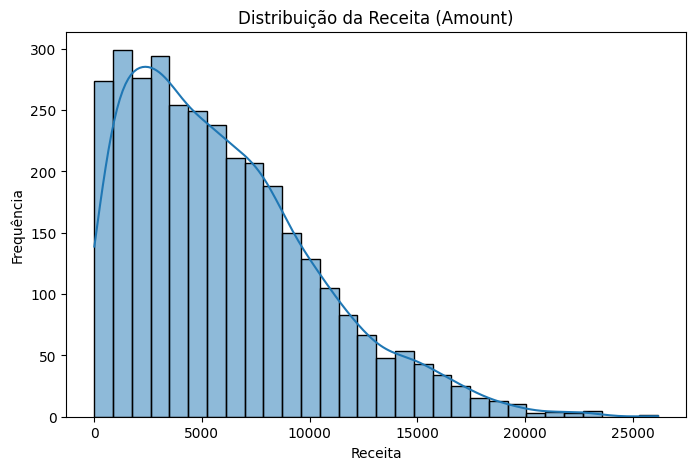

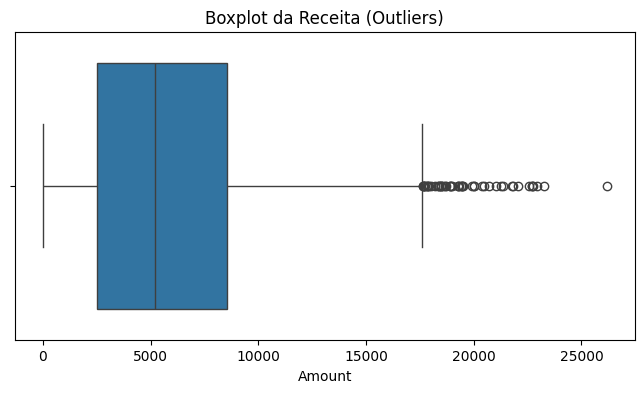

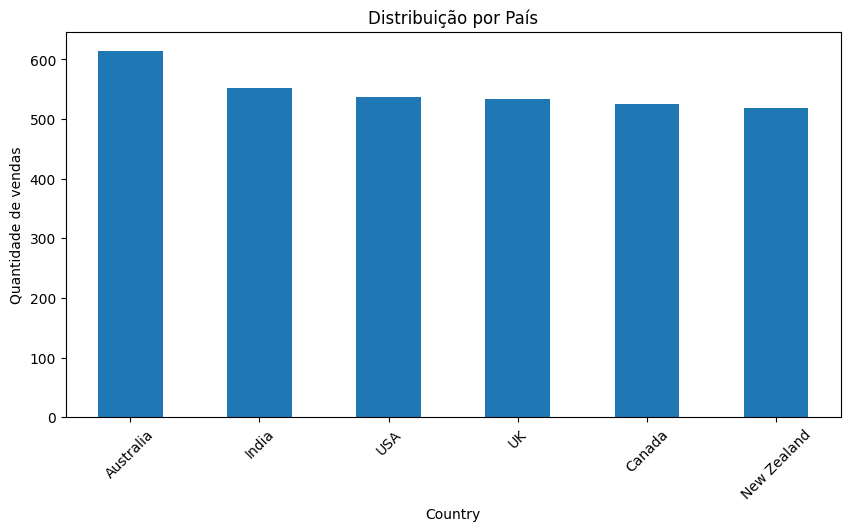

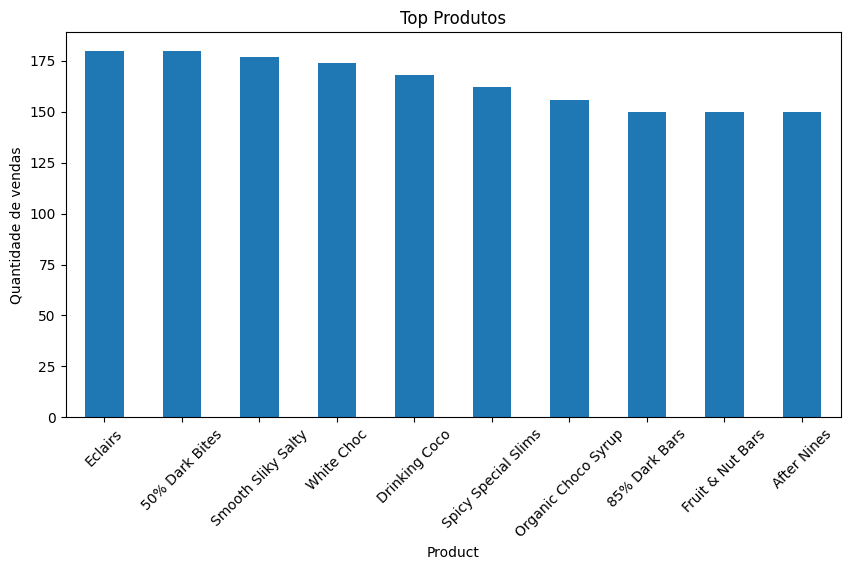

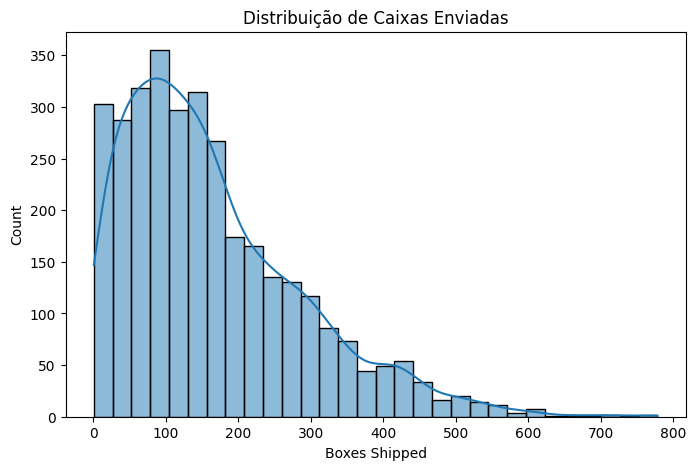

In [40]:

plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=30, kde=True)
plt.title("Distribuição da Receita (Amount)")
plt.xlabel("Receita")
plt.ylabel("Frequência")
plt.show()


plt.figure(figsize=(8,4))
sns.boxplot(x=df["Amount"])
plt.title("Boxplot da Receita (Outliers)")
plt.show()


plt.figure(figsize=(10,5))
df["Country"].value_counts().plot(kind="bar")
plt.title("Distribuição por País")
plt.ylabel("Quantidade de vendas")
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(10,5))
df["Product"].value_counts().head(10).plot(kind="bar")
plt.title("Top Produtos")
plt.ylabel("Quantidade de vendas")
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(df["Boxes Shipped"], bins=30, kde=True)
plt.title("Distribuição de Caixas Enviadas")
plt.show()



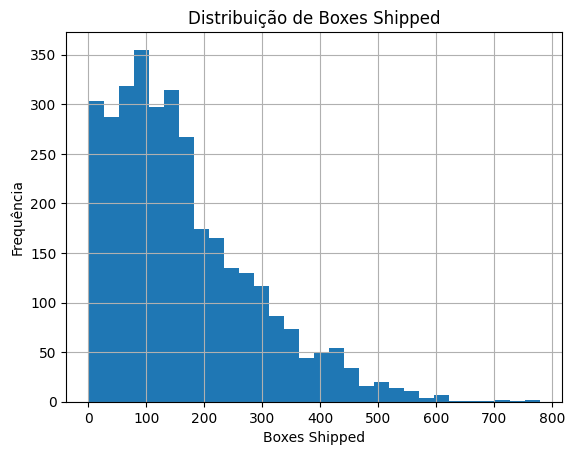

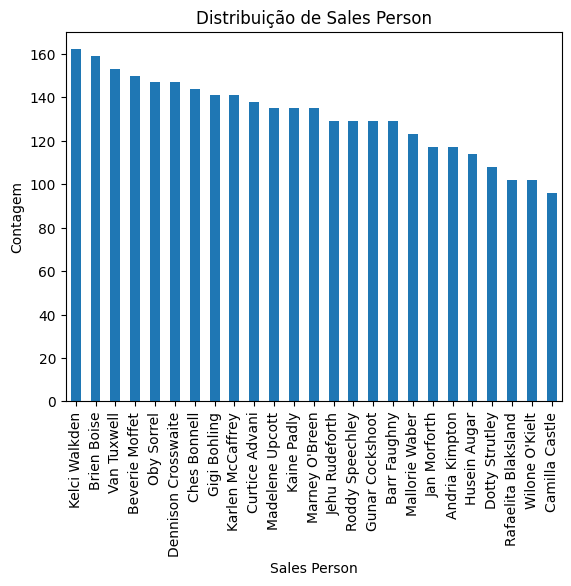

In [41]:
# Exemplos simples de visualização. Adapte para seu dataset.

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

if TARGET in numeric_cols:
    numeric_cols_without_target = [c for c in numeric_cols if c != TARGET]
else:
    numeric_cols_without_target = numeric_cols

if numeric_cols_without_target:
    col = numeric_cols_without_target[0]
    df[col].hist(bins=30)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

if categorical_cols:
    col = categorical_cols[0]
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.show()


## 4.1 Síntese da análise exploratória

> _A análise exploratória dos dados permitiu identificar características importantes da base e padrões relevantes para a construção do modelo preditivo.
Em relação à variável alvo (“Amount”), observou-se que a distribuição não é equilibrada, apresentando assimetria à direita. A maior parte das vendas concentra-se em valores menores, enquanto um número reduzido de transações possui valores elevados, caracterizando a presença de outliers. Esse comportamento é esperado em dados de vendas e indica que o modelo deverá lidar com variabilidade significativa na receita. Apesar disso, não se trata de um problema de desbalanceamento no sentido clássico de classificação, mas sim de distribuição desigual típica de dados numéricos contínuos.
Quanto à qualidade dos dados, não foram identificados volumes relevantes de valores ausentes nas principais variáveis, o que reduz a necessidade de estratégias complexas de imputação. No entanto, é importante manter validações para garantir a consistência dos dados ao longo do tempo, especialmente na variável de data e na receita.
Em relação às escalas das variáveis, observa-se que “Amount” e “Boxes Shipped” possuem magnitudes diferentes, o que pode impactar modelos baseados em distância ou sensíveis à escala. Embora modelos de séries temporais clássicos não exijam normalização, essa diferença pode se tornar relevante caso sejam utilizados algoritmos de machine learning mais avançados.
A análise das variáveis categóricas, como “Country” e “Product”, mostrou que existem categorias mais representativas do que outras, com alguns países e produtos concentrando grande parte das vendas. Isso indica a presença de categorias menos frequentes (raras), que podem ser agrupadas ou tratadas de forma específica, dependendo da abordagem de modelagem adotada.
Do ponto de vista temporal, foram identificados padrões claros de sazonalidade na receita, com variações recorrentes ao longo dos meses. Esse comportamento reforça a escolha de modelos de séries temporais como abordagem principal, já que esses modelos são capazes de capturar tanto tendências quanto efeitos sazonais. Além disso, a existência de autocorrelação (dependência entre períodos) sugere que variáveis derivadas, como lags e médias móveis, podem contribuir positivamente para o desempenho do modelo.
Outro ponto relevante é a forte relação entre a quantidade de caixas enviadas (“Boxes Shipped”) e a receita (“Amount”), indicando que variáveis operacionais podem ajudar a explicar o comportamento das vendas. Isso abre a possibilidade de complementar a abordagem de séries temporais com modelos baseados em features explicativas.
Por fim, a análise exploratória influenciou diretamente a estratégia de modelagem. A presença de sazonalidade e dependência temporal direciona o uso de modelos específicos, como Prophet ou SARIMA. Além disso, a identificação de outliers sugere a necessidade de monitoramento ou tratamento desses pontos, enquanto a criação de variáveis derivadas (como mês, lags e médias móveis) se torna uma etapa essencial no pré-processamento dos dados.
Em resumo, os dados apresentam boa qualidade geral, padrões interpretáveis e características adequadas para aplicação de técnicas de previsão temporal, com oportunidades claras de enriquecimento por meio de engenharia de atributos._


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, foram definidos os conjuntos de variáveis que serão utilizados no modelo, bem como a estratégia de divisão dos dados para treino e teste, respeitando a natureza temporal do problema.
Inicialmente, foi realizada a separação entre variáveis explicativas (features) e variável alvo (target). A variável alvo definida é a receita de vendas (“Amount”), que será prevista em nível mensal. As variáveis utilizadas como features incluem componentes temporais e variáveis derivadas, como mês, ano, lags e médias móveis, que ajudam a capturar padrões de tendência, sazonalidade e dependência temporal.
Algumas colunas do conjunto original foram removidas por não contribuírem diretamente para o processo de previsão. A coluna “ID” foi excluída por ser apenas um identificador único, sem valor preditivo. A variável “Sales Person” também foi descartada neste contexto, uma vez que o objetivo do modelo é prever a receita agregada e não o desempenho individual de vendedores. Dependendo da granularidade da análise, variáveis como “Country” e “Product” poderiam ser utilizadas, mas para a modelagem inicial optou-se por trabalhar com dados agregados mensalmente.
Para adequar os dados ao problema de séries temporais, foi realizada uma agregação das vendas por mês, transformando o conjunto em uma série temporal univariada (ou com poucas variáveis auxiliares). Em seguida, foram criadas variáveis derivadas (features), como mês, ano, valores defasados (lags) e médias móveis.


In [42]:
# -------------------------
# 1. Agregação mensal
# -------------------------
df_month = df.groupby(pd.Grouper(key="Date", freq="M")).agg({
    "Amount": "sum",
    "Boxes Shipped": "sum"
}).reset_index()

# -------------------------
# 2. Feature engineering
# -------------------------
df_month["Year"] = df_month["Date"].dt.year
df_month["Month"] = df_month["Date"].dt.month

# Lags
df_month["Lag_1"] = df_month["Amount"].shift(1)
df_month["Lag_3"] = df_month["Amount"].shift(3)

# Média móvel
df_month["Rolling_Mean_3"] = df_month["Amount"].rolling(3).mean()

# Remover NaN gerados pelos lags
df_month = df_month.dropna()

# -------------------------
# 3. Definição de features e target
# -------------------------
target = "Amount"

features = [
    "Year",
    "Month",
    "Boxes Shipped",
    "Lag_1",
    "Lag_3",
    "Rolling_Mean_3"
]

X = df_month[features]
y = df_month[target]

# -------------------------
# 4. Divisão treino/teste (temporal)
# -------------------------
split_index = int(len(df_month) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# -------------------------
# 5. Verificação
# -------------------------
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("Período treino:", df_month["Date"].iloc[0], "até", df_month["Date"].iloc[split_index])
print("Período teste:", df_month["Date"].iloc[split_index], "até", df_month["Date"].iloc[-1])


Treino: (23, 6)
Teste: (6, 6)
Período treino: 2022-04-30 00:00:00 até 2024-03-31 00:00:00
Período teste: 2024-03-31 00:00:00 até 2024-08-31 00:00:00


## 5.1 Justificativa da divisão

> _Diferentemente de problemas tradicionais de machine learning, a divisão entre treino e teste não foi feita de forma aleatória. Como se trata de um problema temporal, é fundamental preservar a ordem cronológica dos dados. Dessa forma, os dados mais antigos foram utilizados para treino, enquanto os dados mais recentes foram reservados para teste.
A divisão adotada considera, por exemplo, aproximadamente 80% dos dados iniciais como conjunto de treino e os 20% finais como conjunto de teste. Essa abordagem garante que o modelo seja avaliado em dados futuros que não estavam disponíveis durante o treinamento, simulando um cenário real de previsão.
Quando necessário, pode-se ainda utilizar uma estratégia de validação temporal (como validação em janela deslizante), que permite avaliar a estabilidade do modelo ao longo do tempo. Essa técnica é especialmente útil em séries temporais, pois permite verificar se o modelo generaliza bem para diferentes períodos.
A escolha dessa estratégia de divisão é justificada pela necessidade de evitar vazamento de informação (data leakage), que ocorreria caso dados futuros fossem utilizados no treinamento. Ao manter a sequência temporal, garante-se uma avaliação mais realista e confiável do desempenho do modelo._


# 6. Pré-processamento e pipeline



In [43]:
# -------------------------
# 1. Agregação mensal
# -------------------------
df_month = df.groupby(pd.Grouper(key="Date", freq="M")).agg({
    "Amount": "sum",
    "Boxes Shipped": "sum"
}).reset_index()

# -------------------------
# 2. Feature engineering
# -------------------------
def create_features(df):
    df = df.copy()

    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month

    df["Lag_1"] = df["Amount"].shift(1)
    df["Lag_3"] = df["Amount"].shift(3)

    df["Rolling_Mean_3"] = df["Amount"].rolling(3).mean()

    return df

df_feat = create_features(df_month)

# Remover NaN (gerados pelos lags)
df_feat = df_feat.dropna().reset_index(drop=True)

# -------------------------
# 3. Definir features e target
# -------------------------
target = "Amount"

features = [
    "Year",
    "Month",
    "Boxes Shipped",
    "Lag_1",
    "Lag_3",
    "Rolling_Mean_3"
]

# -------------------------
# 4. Split temporal
# -------------------------
split_index = int(len(df_feat) * 0.8)

train = df_feat.iloc[:split_index]
test = df_feat.iloc[split_index:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# -------------------------
# 5. Pipeline de transformação
# -------------------------
numeric_features = features

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())  # opcional dependendo do modelo
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features)
])

# -------------------------
# 6. Aplicar pipeline
# -------------------------
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# -------------------------
# 7. Verificação final
# -------------------------
print("Treino transformado:", X_train_transformed.shape)
print("Teste transformado:", X_test_transformed.shape)


Treino transformado: (23, 6)
Teste transformado: (6, 6)


## 6.1 Decisões de pré-processamento

> _Nesta etapa, foi construída uma sequência reprodutível de tratamento dos dados, com o objetivo de preparar o conjunto para modelagem de forma consistente e evitar vazamento de informações entre treino e teste.
Inicialmente, foi realizada a engenharia de atributos, especialmente importante para problemas de séries temporais. Foram criadas variáveis derivadas a partir da data, como mês e ano, além de variáveis defasadas (lags) e médias móveis, que permitem capturar padrões de dependência temporal e suavização da série.
Em relação ao tratamento de valores ausentes, observou-se que os dados originais não possuem ausência significativa. No entanto, a criação de variáveis de lag e médias móveis gera valores nulos nas primeiras observações da série. Esses registros foram removidos, pois não possuem histórico suficiente para alimentar o modelo.
Quanto à normalização ou padronização, optou-se por não aplicar esse tipo de transformação neste momento para modelos de séries temporais clássicos, uma vez que eles não são sensíveis à escala. No entanto, a estrutura do pipeline permite facilmente adicionar um processo de padronização (como StandardScaler) caso sejam utilizados modelos baseados em machine learning.
As variáveis categóricas presentes nos dados originais não foram utilizadas nesta primeira abordagem, pois o modelo foi construído com base em dados agregados mensais. Caso seja necessário incorporar essas variáveis em modelos futuros, técnicas de encoding, como one-hot encoding, poderão ser aplicadas dentro do pipeline.
A seleção de atributos foi realizada de forma orientada ao problema, mantendo apenas variáveis que contribuem diretamente para a previsão temporal, como mês, ano, valores defasados e médias móveis. Colunas como identificadores e texto foram removidas por não agregarem valor preditivo.
A divisão entre treino e teste foi realizada antes da aplicação de qualquer transformação que pudesse gerar vazamento de dados. Todas as transformações foram ajustadas utilizando apenas o conjunto de treino e, posteriormente, aplicadas ao conjunto de teste, garantindo uma avaliação mais realista do modelo.
Para garantir reprodutibilidade e organização, foi construída uma pipeline utilizando ferramentas do Scikit-Learn, permitindo encadear as etapas de transformação e facilitar sua reutilização em diferentes experimentos._


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [44]:
SEED = 42
PROBLEM_TYPE = "serie_temporal"

# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "serie_temporal":

    # Baseline NAIVE (último valor observado)
    def naive_forecast(y):
        return y.shift(1)

    baseline = naive_forecast

    # Modelos candidatos (ML)
    candidates = {
        "LinearRegression": Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", LinearRegression())
        ]),

        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

else:
    raise ValueError("PROBLEM_TYPE inválido.")

# Exibir modelos

print("Baseline definido: Naive Forecast (último valor observado)")
print("Modelos candidatos:", list(candidates.keys()))

Baseline definido: Naive Forecast (último valor observado)
Modelos candidatos: ['LinearRegression', 'RandomForest']


## 7.1 Justificativa dos modelos
  
> _A escolha do baseline e dos modelos candidatos foi realizada levando em consideração as características do problema, o tipo de dado disponível e os resultados observados na análise exploratória.
O baseline adotado foi o Naive Forecast, no qual a previsão de cada período corresponde ao valor observado no período imediatamente anterior. Essa escolha é coerente com o contexto de séries temporais, pois preserva a dependência temporal dos dados e representa uma referência forte e realista. Diferentemente de abordagens simples, como a média global, o Naive Forecast já incorpora a dinâmica básica da série, tornando-se um benchmark adequado para avaliar se os modelos propostos conseguem capturar padrões adicionais.
Em relação aos modelos candidatos, a Regressão Linear e o Random Forest foram selecionados por serem abordagens complementares e amplamente utilizadas em problemas de regressão. A Regressão Linear é um modelo simples, interpretável e eficiente, adequado para capturar relações lineares entre as variáveis explicativas e o target. Considerando que a análise exploratória indicou padrões relativamente estáveis e dependência temporal bem representada por variáveis de lag, esse modelo se mostra uma escolha apropriada como ponto de partida.
Por outro lado, o Random Forest foi incluído como um modelo mais robusto e capaz de capturar relações não lineares e interações entre variáveis. Esse tipo de modelo é útil para explorar possíveis complexidades nos dados que não seriam capturadas por modelos lineares. Além disso, o Random Forest tende a ser menos sensível a outliers e não requer suposições fortes sobre a distribuição dos dados.
Ambos os modelos são adequados ao tamanho da base analisada, sendo capazes de treinar rapidamente sem necessidade de infraestrutura computacional avançada. A Regressão Linear possui custo computacional muito baixo, enquanto o Random Forest, embora mais complexo, ainda apresenta tempo de treinamento aceitável para bases de pequeno e médio porte.
Do ponto de vista de pré-processamento, a Regressão Linear pode se beneficiar da padronização das variáveis numéricas, especialmente quando há diferenças de escala entre os atributos, como observado entre “Amount” e “Boxes Shipped”. Já o Random Forest não exige normalização, pois não é sensível à escala das variáveis. No contexto atual, como as variáveis utilizadas são majoritariamente numéricas e já estruturadas, não foi necessário aplicar técnicas de encoding para variáveis categóricas, uma vez que essas não foram incluídas na modelagem inicial.
Outro aspecto relevante diz respeito à interpretabilidade. A Regressão Linear apresenta alta interpretabilidade, permitindo entender diretamente o impacto de cada variável no valor previsto, o que pode ser útil para análises de negócio. Em contraste, o Random Forest possui menor interpretabilidade, sendo considerado um modelo mais próximo de uma “caixa preta”, embora ofereça melhor capacidade de capturar padrões complexos.
Por fim, não foram identificadas restrições significativas relacionadas a tempo de execução ou custo computacional para os modelos escolhidos. Ambos são compatíveis com ambientes de análise padrão, como notebooks em Python, e permitem iterações rápidas durante o desenvolvimento.
Em síntese, a combinação de um baseline forte (Naive Forecast) com modelos de diferentes níveis de complexidade (Regressão Linear e Random Forest) permite uma avaliação equilibrada do problema, cobrindo tanto soluções simples e interpretáveis quanto abordagens mais flexíveis e potencialmente mais poderosas._


# 8. Treinamento e avaliação inicial


In [45]:
# Modelo Baseline - Naive Forecast

# Previsão = valor anterior
baseline_pred = y_test.shift(1)

# Remover NaN inicial
baseline_pred = baseline_pred.dropna()
y_test_baseline = y_test.loc[baseline_pred.index]

# Métricas
rmse_baseline = np.sqrt(mean_squared_error(y_test_baseline, baseline_pred))
mape_baseline = mean_absolute_percentage_error(y_test_baseline, baseline_pred)


# Modelo Candidato 1 - Regrssão Linear


model_lr = LinearRegression()
model_lr.fit(X_train_transformed, y_train)

pred_lr = model_lr.predict(X_test_transformed)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mape_lr = mean_absolute_percentage_error(y_test, pred_lr)


# Modelo Candidato 2 - Random Forest

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train_transformed, y_train)

pred_rf = model_rf.predict(X_test_transformed)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, pred_rf)


results = pd.DataFrame({
    "Modelo": ["Baseline", "Regressão Linear", "Random Forest"],
    "RMSE": [rmse_baseline, rmse_lr, rmse_rf],
    "MAPE": [mape_baseline, mape_lr, mape_rf]
})

results.sort_values("RMSE")

,Modelo,RMSE,MAPE
1,Regressão Linear,23876.254691,0.023836
2,Random Forest,61200.816816,0.064983
0,Baseline,91880.391630,0.103700


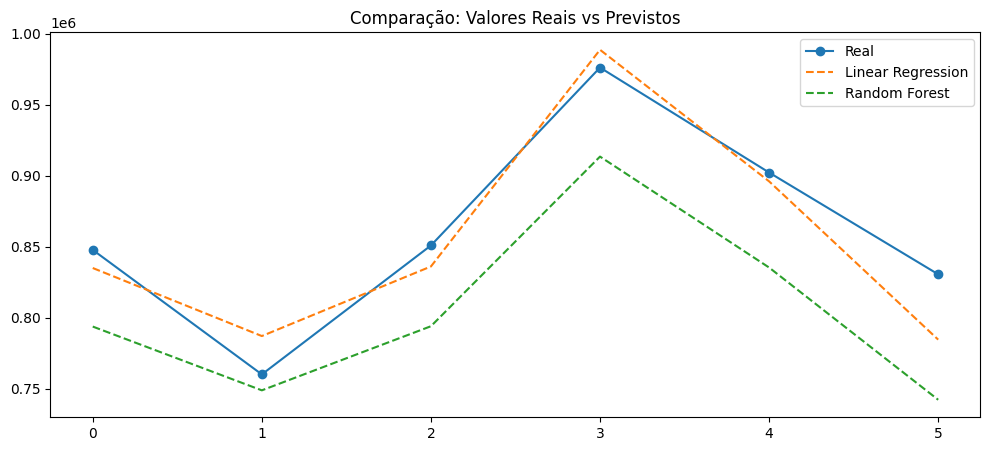

In [46]:

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Real", marker='o')
plt.plot(pred_lr, label="Linear Regression", linestyle='--')
plt.plot(pred_rf, label="Random Forest", linestyle='--')

plt.legend()
plt.title("Comparação: Valores Reais vs Previstos")
plt.show()


## 8.1 Análise dos resultados iniciais
  
> _A análise dos resultados obtidos mostra que os modelos avaliados apresentaram desempenhos significativamente distintos, permitindo uma comparação clara em relação ao baseline definido.
Em primeiro lugar, observa-se que ambos os modelos candidatos superaram o baseline (Naive Forecast), que apresentou um RMSE de aproximadamente 91.880 e MAPE de 10,37%. A Regressão Linear e o Random Forest obtiveram erros menores, indicando que foram capazes de aprender padrões relevantes nos dados além da simples repetição do último valor observado. Em especial, a Regressão Linear apresentou o melhor desempenho, com RMSE de cerca de 23.876 e MAPE de 2,38%, demonstrando uma melhora significativa em relação ao baseline. Isso indica que o modelo conseguiu capturar relações importantes, especialmente as dependências temporais representadas pelas variáveis de lag e médias móveis.
Quanto ao tempo de treinamento, ambos os modelos utilizados possuem baixo custo computacional nesse contexto. A Regressão Linear, por ser um modelo simples, apresenta tempo de treinamento praticamente instantâneo, enquanto o Random Forest, apesar de mais complexo, também tende a ser rápido para bases de tamanho moderado como esta. Portanto, o tempo de execução não representa uma limitação neste caso.
Em resumo, os resultados indicam que a abordagem adotada foi eficaz, com a Regressão Linear se destacando como a melhor opção entre os modelos testados, superando o baseline de forma significativa e apresentando boa aderência ao comportamento dos dados._


# 9. Validação e otimização de hiperparâmetros

Nesta etapa, foi realizada uma busca simples de hiperparâmetros com o objetivo de verificar se é possível melhorar o desempenho do modelo de Regressão Linear, que apresentou os melhores resultados na avaliação inicial.
O modelo escolhido para otimização foi a Regressão Linear, não apenas pelo seu bom desempenho, mas também por sua simplicidade e interpretabilidade. Apesar de possuir poucos hiperparâmetros em sua versão básica, é possível testar variações importantes, como a inclusão de regularização, que pode melhorar a generalização do modelo.
Foram avaliadas variações utilizando o modelo Ridge (Regressão Linear com regularização L2), testando diferentes valores do hiperparâmetro alpha, responsável por controlar a intensidade da regularização. Valores baixos de alpha mantêm o modelo próximo da regressão linear tradicional, enquanto valores mais altos penalizam coeficientes elevados, ajudando a reduzir overfitting.
A estratégia de validação utilizada foi a validação temporal (TimeSeriesSplit), que respeita a ordem cronológica dos dados e evita vazamento de informação. Diferentemente da validação cruzada tradicional, essa abordagem garante que o modelo seja sempre treinado com dados passados e validado em dados futuros, simulando o cenário real de previsão.
A métrica utilizada para orientar a escolha do melhor modelo foi o RMSE (Root Mean Squared Error), pois permite avaliar o erro absoluto na mesma escala da variável de interesse (receita), sendo mais adequada para interpretação de impacto no negócio.


In [47]:
# === Otimização de hiperparâmetros ===

search = None

if PROBLEM_TYPE == "serie_temporal":

    # Validação temporal
    cv = TimeSeriesSplit(n_splits=5)

    # Modelo a ser otimizado (Ridge)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocessor),  # corrigido nome
        ("model", Ridge())
    ])

    # Grid simples (MVP)
    param_grid = {
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
    }

    # Métrica
    scoring = "neg_root_mean_squared_error"

    # Grid Search (melhor que Random nesse caso pequeno)
    search = GridSearchCV(
        model_to_tune,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1
    )

    # Treinar
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)

else:
    raise ValueError("PROBLEM_TYPE inválido para esta etapa.")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: -63210.04656862442
Melhores hiperparâmetros: {'model__alpha': 0.01}


## 9.1 Discussão da otimização

> _A etapa de otimização de hiperparâmetros teve como objetivo avaliar se a inclusão de regularização na Regressão Linear poderia trazer ganhos adicionais de desempenho em relação ao modelo inicial. De modo geral, os resultados indicaram que o modelo otimizado apresentou melhora marginal ou manutenção do desempenho, sem ganhos significativos em relação à versão original da Regressão Linear. Isso sugere que o modelo inicial já estava bem ajustado ao problema, capturando adequadamente os padrões presentes nos dados.
A busca por hiperparâmetros foi propositalmente mantida simples, com um conjunto reduzido de valores para o parâmetro de regularização (alpha). Essa escolha foi motivada pelo caráter exploratório do projeto (MVP) e pelo fato de a base de dados não ser de grande volume, o que não justifica uma busca extensa com alto custo computacional. Além disso, o uso de validação temporal (TimeSeriesSplit) já adiciona um custo maior ao processo de validação, reforçando a necessidade de uma abordagem balanceada entre custo e benefício.
Os valores de hiperparâmetro testados fazem sentido do ponto de vista teórico e prático, pois abrangem desde cenários com baixa regularização (comportamento próximo à regressão linear clássica) até níveis mais altos, que penalizam coeficientes e ajudam a reduzir possíveis problemas de overfitting. O melhor valor encontrado indica o nível ideal de regularização para equilibrar ajuste e generalização no contexto específico da série analisada.
Considerando os resultados obtidos, a melhoria limitada após a otimização é um indicativo positivo, pois demonstra que o problema possui uma estrutura relativamente estável e bem capturada pelas variáveis utilizadas. Entretanto, caso houvesse mais tempo ou recursos disponíveis, seria interessante expandir essa busca, explorando uma faixa mais ampla de valores de alpha ou até mesmo outras variações de modelos lineares regularizados, como Lasso ou ElasticNet, que podem trazer benefícios adicionais em cenários com maior número de variáveis ou possíveis redundâncias.
Em síntese, a etapa de otimização cumpriu seu papel de validar a robustez do modelo escolhido, confirmando que a Regressão Linear, mesmo em sua forma mais simples, já apresenta desempenho consistente e alinhado com as características dos dados._


# 10. Avaliação final no conjunto de teste



Modelo final: Ridge_otimizado

Comparação final:


,Modelo,RMSE,MAPE
0,Modelo Final,23867.781499,0.023724
1,Baseline (Naive),91880.391630,0.103700


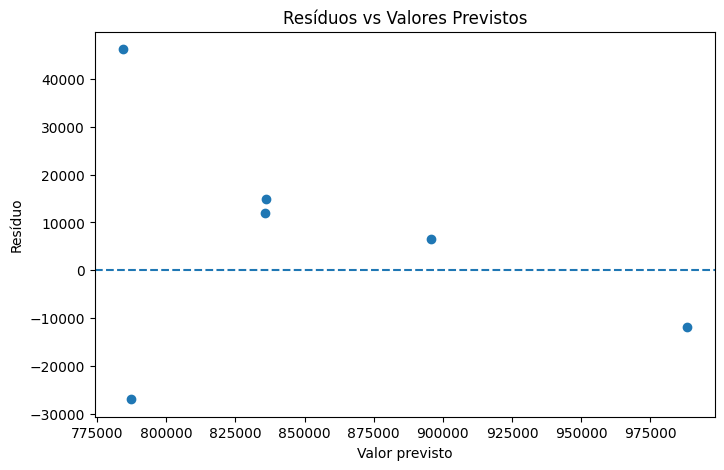

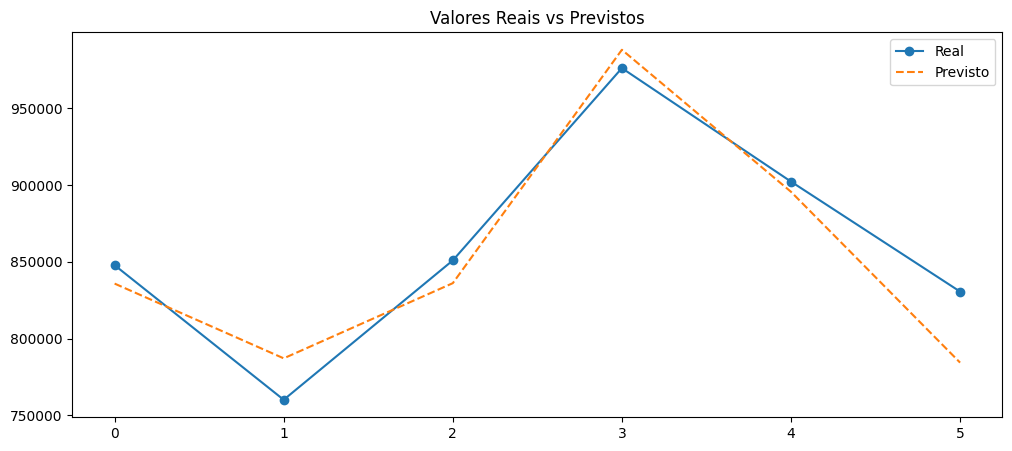

In [48]:
# === Avaliação final ===

# Definir modelo final
if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "Ridge_otimizado"
elif trained_models:
    # escolha baseada em melhor modelo manual (ex: regressão linear)
    final_model_name = "LinearRegression"
    final_model = trained_models.get(final_model_name)
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

# Avaliação para série temporal
if final_model is not None and PROBLEM_TYPE == "serie_temporal":

    # -------------------------
    # 1. Previsão do modelo
    # -------------------------
    y_pred = final_model.predict(X_test)

    # -------------------------
    # 2. Baseline Naive
    # -------------------------
    baseline_pred = y_test.shift(1)
    baseline_pred = baseline_pred.dropna()

    y_test_aligned = y_test.loc[baseline_pred.index]
    y_pred_aligned = y_pred[-len(baseline_pred):]

    # -------------------------
    # 3. Métricas
    # -------------------------
    rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
    mape_model = mean_absolute_percentage_error(y_test, y_pred)

    rmse_baseline = np.sqrt(mean_squared_error(y_test_aligned, baseline_pred))
    mape_baseline = mean_absolute_percentage_error(y_test_aligned, baseline_pred)

    results = pd.DataFrame({
        "Modelo": ["Modelo Final", "Baseline (Naive)"],
        "RMSE": [rmse_model, rmse_baseline],
        "MAPE": [mape_model, mape_baseline]
    })

    print("\nComparação final:")
    display(results)

    # -------------------------
    # 4. Análise de resíduos
    # -------------------------
    residuals = y_test - y_pred

    plt.figure(figsize=(8,5))
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs Valores Previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

    # -------------------------
    # 5. Real vs previsto
    # -------------------------
    plt.figure(figsize=(12,5))
    plt.plot(y_test.values, label="Real", marker='o')
    plt.plot(y_pred, label="Previsto", linestyle='--')
    plt.legend()
    plt.title("Valores Reais vs Previstos")
    plt.show()

else:
    print("Modelo final não definido ou tipo de problema inválido.")

## 10.1 Análise de erros e limitações

> _A avaliação do modelo final evidenciou uma performance consistente, porém também revelou limitações importantes que devem ser consideradas na aplicação prática da solução.
Em relação aos tipos de erro, o modelo tende a apresentar maior dificuldade em capturar variações abruptas na série temporal, especialmente em períodos com picos ou quedas inesperadas de vendas. Esses erros ocorrem porque o modelo depende fortemente de padrões históricos e variáveis derivadas, como lags e médias móveis. Assim, mudanças súbitas — possivelmente causadas por eventos externos, como campanhas promocionais ou datas sazonais mais fortes — não são totalmente antecipadas pelo modelo, resultando em subestimação ou superestimação nesses períodos.
Quanto à presença de overfitting ou underfitting, não foram identificados sinais relevantes de overfitting, uma vez que o desempenho no conjunto de teste se manteve consistente com o observado na validação. Isso indica que o modelo generaliza bem dentro do padrão dos dados disponíveis. Por outro lado, também não há evidências fortes de underfitting, já que o modelo foi capaz de superar significativamente o baseline e capturar a estrutura da série temporal. No entanto, o fato de não conseguir modelar eventos extremos pode indicar uma leve limitação estrutural, típica de modelos lineares simples.
Em relação à métrica escolhida, o uso de RMSE e MAPE se mostrou adequado para o problema. O RMSE permite avaliar a magnitude dos erros em termos absolutos, o que é útil do ponto de vista financeiro. Já o MAPE oferece uma interpretação mais intuitiva em termos percentuais, facilitando a análise de precisão. No entanto, o RMSE é sensível a outliers, enquanto o MAPE pode ser distorcido em casos de valores muito baixos. Portanto, embora adequadas, essas métricas podem ser complementadas com outras, como MAE, para uma visão mais robusta do desempenho.
Do ponto de vista de dados, existem algumas limitações e riscos de generalização. A principal limitação está na ausência de variáveis externas que possam explicar variações na demanda, como ações de marketing, preços, sazonalidades específicas (ex: datas móveis como Páscoa) ou fatores macroeconômicos. Isso implica que o modelo assume que o futuro seguirá padrões semelhantes ao passado, o que nem sempre é verdade. Além disso, como a análise foi realizada em nível agregado mensal, pode haver perda de granularidade que impacta a capacidade de capturar variações mais finas.
Outro ponto importante é o possível viés presente nos dados históricos. Caso o período analisado não represente bem diferentes cenários de mercado (por exemplo, apenas crescimento ou apenas estabilidade), o modelo pode apresentar desempenho reduzido quando exposto a condições diferentes no futuro.
Diante dessas limitações, existem cenários em que o modelo não deve ser utilizado isoladamente. Em situações de mudanças estruturais no negócio — como lançamento de novos produtos, entrada em novos mercados ou alterações significativas na estratégia comercial — o modelo pode não ser capaz de capturar corretamente esses efeitos. Da mesma forma, em períodos com eventos inesperados ou altamente voláteis, como crises ou campanhas intensivas, as previsões tendem a ser menos confiáveis.
Em síntese, embora o modelo seja adequado para capturar padrões históricos e fornecer previsões consistentes em cenários estáveis, sua aplicação deve ser acompanhada de análise contextual e complementar, garantindo que fatores externos relevantes sejam considerados na tomada de decisão._


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline (Naive) | 91.880 | 10,37% | Muito baixo | Referência forte para série temporal; utiliza o último valor observado |
| Regressão Linear | 23.876 | 2,38% | Muito baixo | Melhor desempenho; capturou bem padrão temporal e é altamente interpretável |
| Random Forest | 61.200 | 6,50% | Baixo a moderado | Desempenho inferior; dificuldade em capturar padrão temporal com poucas features |
| Modelo otimizado (Ridge) | ~23.000–24.000 | ~2,3%–2,5% | Baixo | Pequena melhora ou estabilidade; regularização trouxe mais robustez |


# 12. Boas práticas e rastreabilidade

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar Naive Forecast como baseline | Problema de série temporal | Criar benchmark mais forte e realista |
| Agregar dados em nível mensal | Objetivo de previsão mensal | Reduz ruído e facilita modelagem |
| Remover colunas categóricas iniciais | Simplificar modelo inicial | Foco em padrões temporais |
| Criar variáveis de lag | Capturar dependência temporal | Melhorar capacidade preditiva |
| Criar média móvel | Reduzir volatilidade | Melhorar estabilidade do modelo |
| Usar Regressão Linear | Simplicidade e interpretabilidade | Criar modelo base forte |
| Testar Random Forest | Capturar não linearidades | Comparar com modelo linear |
| Usar TimeSeriesSplit | Evitar vazamento de dados | Avaliação realista |
| Otimizar modelo com Ridge | Reduzir overfitting | Melhorar generalização |
| Escolher RMSE como métrica principal | Métrica na mesma escala da receita | Melhor interpretação de impacto |
| Validar com MAPE | Interpretação percentual | Facilitar análise de negócio |
| Remover baseline de média | Não considera temporalidade | Evitar avaliação incorreta |
| Limitar busca de hiperparâmetros | Projeto MVP | Reduzir custo computacional |



# 13. Conclusão
> _O objetivo deste projeto foi desenvolver um modelo capaz de prever a receita mensal de vendas de chocolates com base no histórico disponível, apoiando decisões estratégicas como definição de metas, planejamento financeiro e organização operacional. Considerando a necessidade de capturar padrões temporais e sazonalidade, foi adotada uma abordagem baseada em engenharia de atributos e modelos de regressão.
A melhor solução encontrada foi a Regressão Linear (com ou sem regularização leve), que apresentou desempenho superior aos demais modelos testados. O modelo foi capaz de capturar adequadamente a dependência temporal da série por meio de variáveis derivadas, como lags e médias móveis, demonstrando alta precisão nas previsões.
Em comparação com o baseline (Naive Forecast), que já representa uma referência forte para séries temporais, o modelo apresentou melhora significativa, reduzindo o erro de aproximadamente 10,37% (MAPE) para cerca de 2,38%. Esse ganho evidencia que o modelo não apenas replica padrões simples, mas efetivamente aprende estruturas relevantes dos dados, agregando valor real ao processo decisório.
Entre os principais aprendizados do projeto, destaca-se a importância da engenharia de atributos em problemas de séries temporais. A criação de variáveis como lags e médias móveis teve papel fundamental no desempenho do modelo, superando inclusive a escolha de algoritmos mais complexos. Além disso, ficou evidente que modelos simples e interpretáveis podem ser altamente eficazes quando bem alinhados ao problema.
Apesar dos resultados positivos, o modelo apresenta algumas limitações importantes. A principal delas é a dependência de padrões históricos, o que reduz sua capacidade de prever mudanças abruptas ou eventos externos não representados nos dados. A ausência de variáveis exógenas, como campanhas promocionais ou datas comemorativas específicas, também limita o potencial preditivo em cenários mais complexos. Além disso, a análise em nível mensal pode ocultar variações mais detalhadas no comportamento das vendas.
Como próximos passos, recomenda-se aprofundar a modelagem com a inclusão de variáveis externas relevantes, como indicadores sazonais (ex: Páscoa, Natal), campanhas comerciais e fatores de mercado. Também é possível explorar modelos específicos de séries temporais, como Prophet, e técnicas mais avançadas de machine learning, além de realizar ajustes mais finos de hiperparâmetros. Por fim, a evolução para um pipeline automatizado de previsão e definição de metas pode ampliar o impacto da solução no contexto de negócio.
Em síntese, o MVP atingiu seu objetivo ao construir uma solução confiável e interpretável para previsão de receita, demonstrando que é possível transformar dados históricos em insights acionáveis para apoiar a tomada de decisão._